In [62]:
from phd_helpers.paramOptimisation.getInfo import get_params3d, get_runtimes, combine_metric_dfs
from phd_helpers.paths import get_info_df, get_subject_stl_path, get_mesh, avg_edge_length


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('../../../../MeshPipeline/outputs/ParamOptimisation/optimise3D') # path to parent of output_root in set_parameters
out_dir = Path('outputs/study1') # path dir to save outputs in

study_prefix = 'study1' # start of dir name of output_root in set_parameters
studies = ['a', 'b', 'c'] # individual study identifier (end of dir name of output_root in set_parameters)

 - First ran for subject 14548 81x3  (full_params)
 - Then ran for 50045R (full_params-1)
     - but had to rerun study1c as it had not finished 14548R when 50045R was started, which caused cgal IO errors

In [4]:
extra_params = ['cgal_params.sizing_field.d0']
params1 = get_params3d(root_dir, study_prefix, studies[:2], extra_params)
params2 = get_params3d(root_dir, study_prefix, studies[:2], extra_params, 'full_params-1.json')
params3 = get_params3d(root_dir, study_prefix, studies[-1:], extra_params, 'full_params-2.json')
pd.concat((params1, params2, params3)).to_csv(out_dir / 'params.csv', index=False)

runs1 = get_runtimes(root_dir, study_prefix, studies[:2])
runs2 = get_runtimes(root_dir, study_prefix, studies[-1:], 'full_params-2.json')
pd.concat((runs1, runs2)).to_csv(out_dir / 'runtimes.csv', index=False)

import subprocess
path_computeMetrics = '../computeMetrics3d.py'
for study in studies[-1:]:
    study_dir = root_dir / (study_prefix + study)
    subprocess.run(["python", path_computeMetrics, study_dir, out_dir, 'full_params-2.json', study])

In [ ]:
info = get_info_df('CMC')

df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, ['study1a-0a', 'study1a-1a', 'study1b-0b', 'study1b-1b', 'study1c-2c'])
df_qual['tets_vol'] = df_qual['total_tets'] / df_qual['total_vol']
#df_bone.to_csv(out_dir / 'df_bone.csv', index=False)
#df_qual.to_csv(out_dir / 'df_qual.csv', index=False)
#df_cart.to_csv(out_dir / 'df_cart.csv', index=False)

df_run = pd.read_csv(out_dir / 'runtimes.csv')
df_param = pd.read_csv(out_dir / 'params.csv')
df_param

,sub,bone,run_id,cgal_params.sizing_field.d0,cgal_params.lloyd.convergence,cgal_params.lloyd.freeze_bound,cgal_params.perturb.sliver_bound,cgal_params.exude.sliver_bound
0,14548R,tpm,0-0a,2,0.0100,0.0100,0,0
1,14548R,tpm,1-0a,2,0.0100,0.0100,0,10
2,14548R,tpm,2-0a,2,0.0100,0.0100,0,20
3,14548R,tpm,3-0a,2,0.0100,0.0100,10,0
4,14548R,tpm,4-0a,2,0.0100,0.0100,10,10
...,...,...,...,...,...,...,...,...
481,50045R,tpm,76-2c,8,0.0025,0.0025,10,10
482,50045R,tpm,77-2c,8,0.0025,0.0025,10,20
483,50045R,tpm,78-2c,8,0.0025,0.0025,20,0
484,50045R,tpm,79-2c,8,0.0025,0.0025,20,10


In [142]:
d_metric = 'max'
iteration_cart = 'orig'
iteration_bone = 'orig'
loc = 'i'

qual_metric = '99%'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_rmsd{loc}',
    f'bone_{iteration_bone}_d{loc}_{d_metric}',
    f'cart_{iteration_cart}_rmsd{loc}',
    f'cart_{iteration_cart}_d{loc}_{d_metric}',

    # quality (keep high)
    f'cart_inner_min_angle_{qual_metric}',
    f'cart_inner_scaled_jacobian_{qual_metric}',
    'cart_inner_min_angle_worst',
    'cart_inner_scaled_jacobian_worst',

    # cell count (keep low)
    'total_tets'

]


bone = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_rmsd{loc}', f'{iteration_bone}_d{loc}_{d_metric}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_rmsd{loc}': f'bone_{iteration_bone}_rmsd{loc}',
    f'{iteration_bone}_d{loc}_{d_metric}': f'bone_{iteration_bone}_d{loc}_{d_metric}'
})

cart = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_rmsd{loc}', f'{iteration_cart}_d{loc}_{d_metric}']
].rename(columns={
    f'{iteration_cart}_rmsd{loc}': f'cart_{iteration_cart}_rmsd{loc}',
    f'{iteration_cart}_d{loc}_{d_metric}': f'cart_{iteration_cart}_d{loc}_{d_metric}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        f'cart_inner_min_angle_{qual_metric}',
        f'cart_inner_scaled_jacobian_{qual_metric}',
        'cart_inner_min_angle_worst',
        'cart_inner_scaled_jacobian_worst',
        f'cart_inner_aspect_ratio_{qual_metric}',
        f'cart_inner_radius_ratio_{qual_metric}',
        'cart_inner_aspect_ratio_worst',
        'cart_inner_radius_ratio_worst',
        'total_tets',
        'tets_vol'
    ]
]

df = (
    bone
    .merge(cart, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)

14548R - Average edge length: 0.3605 mm
50045R - Average edge length: 0.3666 mm


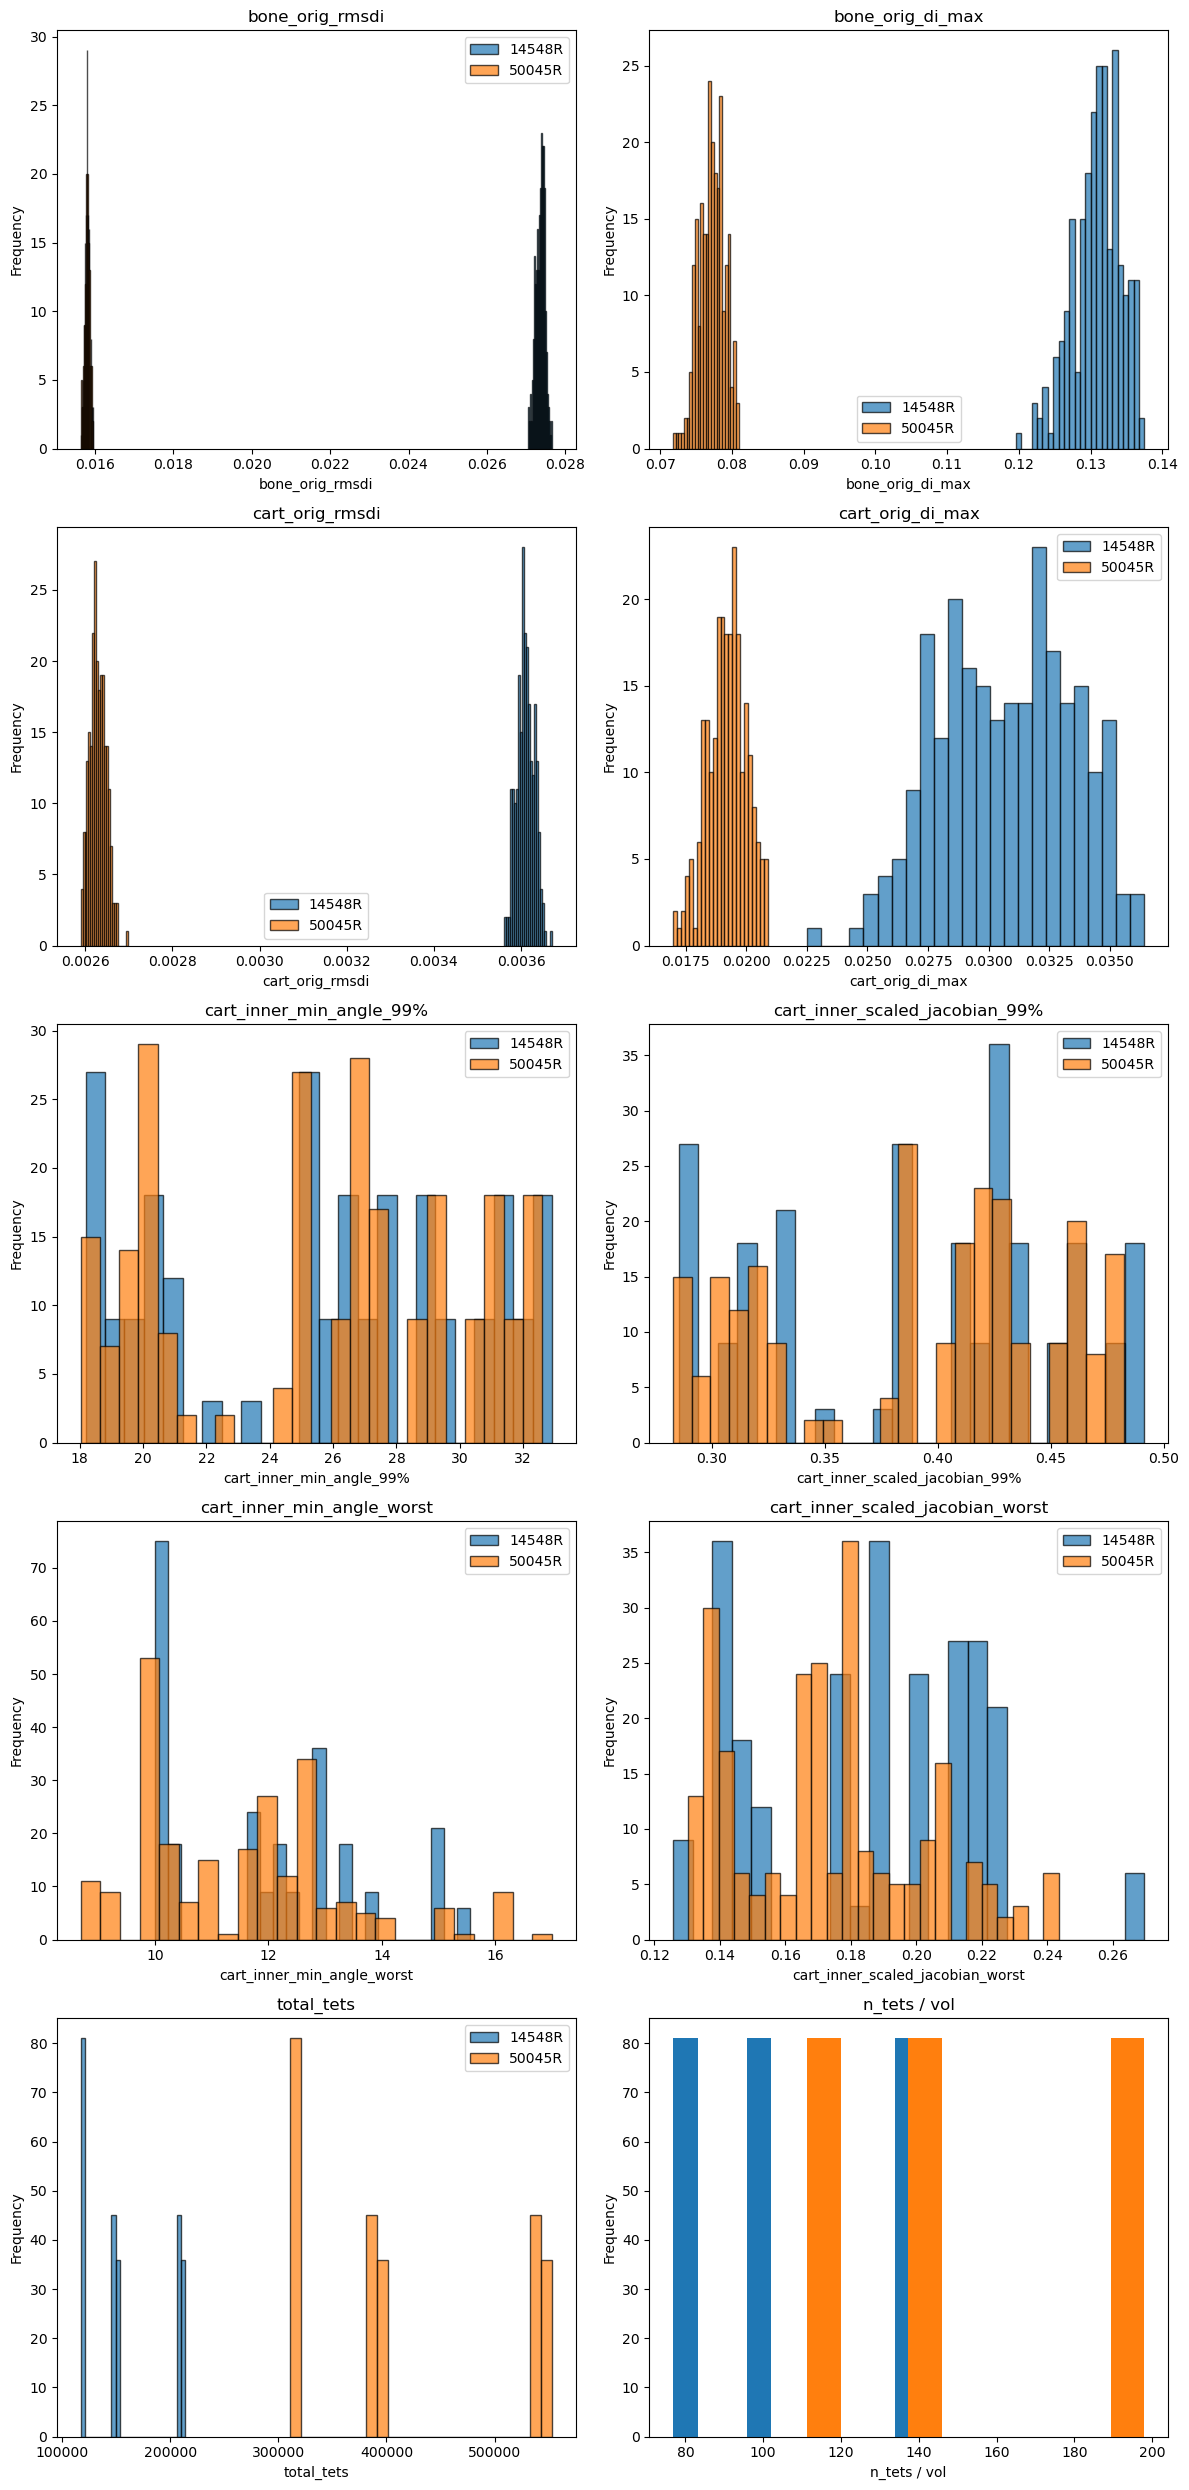

In [143]:
fig, ax = plt.subplots(5, 2, figsize=(12, 25))
ax = ax.flatten()


for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    orig_vol = info[(info['subject']==int(subject)) & (info['side']==side)]['tpm_volume'].values
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    print(f"{sub} - Average edge length: {L:.4f} mm")

    sub_df = df[df['sub']==sub]
    bins = round(len(sub_df) / 10)
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        ax[i].legend()

    #ax[-1].hist(100 * (sub_df['remesh3d_vol'].values - orig_vol) / orig_vol, bins=bins, edgecolor='black', alpha=0.7)
    ax[-1].hist(sub_df['tets_vol'])
    ax[-1].set_title("n_tets / vol")
    ax[-1].set_xlabel("n_tets / vol")
    ax[-1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Thoughts
 - Not too bothered about bone volume here because we have allowed the rest of the bone to deviate quite a lot
 - cart inner distance from orig is < 0.05 and negligable from remesh for all params, so that's good
 - bone inner distance from orig is within 0.15 of orig for all params, which is great cose min edge length was 0.3 to start with so 0.15 is ideal for suggesting the staircasing is correctly accounted for,  and less importantly within 0.02 of remesh2d

# Scoring
 - Score between 0 -> 1
 - Pick ideal value where values of ideal -> are given a score of 1
 - Pick acceptable value where for values between acceptable -> ideal scores are scaled linearly
 - Values between <- acceptable are scaled exponentially


In [ ]:
def score_value(x, ideal, acceptable, linear_floor=0.5, decay=5.0):
    """
    Score values in [0, 1] with:
      - score = 1 at and beyond the ideal region
      - linear scaling between acceptable and ideal
      - exponential drop-off beyond acceptable toward 0"""

    x = np.asarray(x, dtype=float)
    score = np.empty_like(x, dtype=float)

    if acceptable <= ideal: # bigger better
        # ideal or better -> 1
        mask_ideal = x >= ideal
        score[mask_ideal] = 1.0

        # acceptable to ideal -> linear from linear_floor to 1
        mask_linear = (x >= acceptable) & (x < ideal)
        score[mask_linear] = linear_floor + (
            (x[mask_linear] - acceptable) / (ideal - acceptable)
        ) * (1.0 - linear_floor)

        # below acceptable -> exponential decay from linear_floor toward 0
        mask_exp = x < acceptable
        score[mask_exp] = linear_floor * np.exp(
            decay * (x[mask_exp] - acceptable) / (ideal - acceptable)
        )

    else:
        # ideal or better -> 1
        mask_ideal = x <= ideal
        score[mask_ideal] = 1.0

        # ideal to acceptable -> linear from 1 to linear_floor
        mask_linear = (x > ideal) & (x <= acceptable)
        score[mask_linear] = linear_floor + (
            (acceptable - x[mask_linear]) / (acceptable - ideal)
        ) * (1.0 - linear_floor)

        # above acceptable -> exponential decay from linear_floor toward 0
        mask_exp = x > acceptable
        score[mask_exp] = linear_floor * np.exp(
            -decay * (x[mask_exp] - acceptable) / (acceptable - ideal)
        )

    score = np.clip(score, 0.0, 1.0)

    if score.ndim == 0:
        return float(score)
    return score

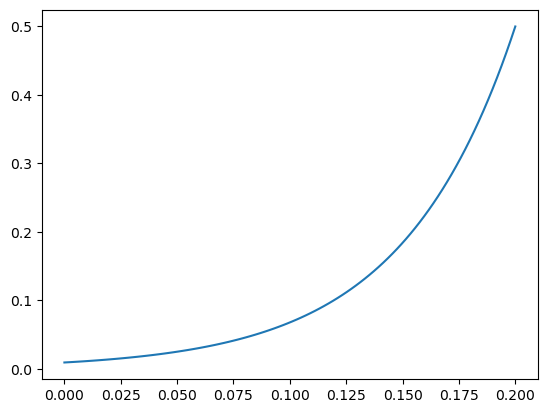

In [76]:
# tune decay
x = np.linspace(0, 0.2, 100)
linear_floor = 0.5
decay = 4
acceptable = 0.2
ideal = 0.4
y = linear_floor * np.exp(
            decay * (x - acceptable) / (ideal - acceptable)
        )

plt.plot(x, y)

- For both cartilage and bone distance measures, there are no sharp features so only expect enough movement to smooth out ridges in cartilge around channels and smooth out staircasing in the bone.
 Difficult to estimate the size of movement needed to fix cartilage channels but chose a max value of 0.05mm to not exceed <10\% of average cartilage height, whilst ensuring 99\% stayed below some other value, gives enough room to smooth out fine ridges but ensures overall shape and height is not affected.
 For bone surface know we need around 0.15 to smooth out staircasing when element size of orig ranged from 0.3 to 0.5 so limit was chosen to be 0.25mm?
  - Need to also consider image resolution when talking about this.

 - Since all meshes have great distance metrics don't even need to consider those, can just optimise for element quality and minimise element count

In [152]:
#d_weight = 1
q_weight = 1 
t_weight = 3

chosen_metrics = {
    #'bone_orig_di_max': {
    #    'ideal': 0.15,
    #    'acceptable': 0.25,
    #    'weight': d_weight
    #},
    #'cart_orig_di_max': {
    #    'ideal': 0.025,
    #    'acceptable': 0.05,
    #    'weight': d_weight
    #},

    #'cart_inner_min_angle_99%': {
    #    'ideal': 30,
    #    'acceptable': 15,
    #    'weight': q_weight
    #},
    'cart_inner_min_angle_worst': {
        'ideal': 15,
        'acceptable': 10,
        'weight': q_weight
    },
    #'cart_inner_scaled_jacobian_99%': {
    #    'ideal': 0.4,
    #    'acceptable': 0.3,
    #    'weight': q_weight
    #},
    'cart_inner_scaled_jacobian_worst': {
        'ideal': 0.3,
        'acceptable': 0.2,
        'weight': q_weight
    },

    #'cart_inner_aspect_ratio_99%': {
    #    'ideal': 3,
    #    'acceptable': 4,
    #    'weight': q_weight
    #},
    'cart_inner_aspect_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },
    #'cart_inner_radius_ratio_99%': {
    #    'ideal': 3,
    #    'acceptable': 4,
    #    'weight': q_weight
    #},
    'cart_inner_radius_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },


    'tets_vol': {
        'ideal': 120,
        'acceptable': 150,
        'weight': t_weight
    }
}

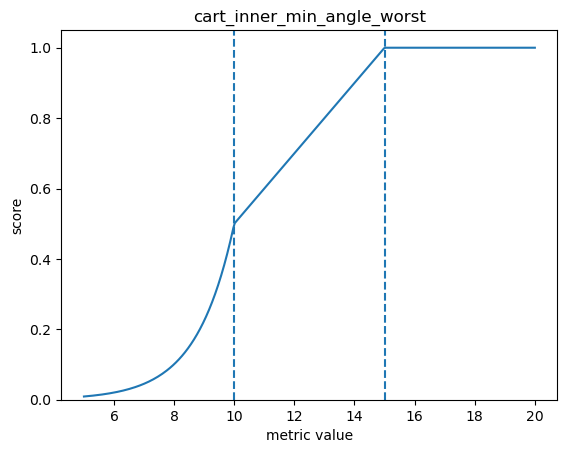

In [102]:
metric = 'cart_inner_min_angle_worst'
bounds = chosen_metrics[metric]
a = bounds['acceptable']
i = bounds['ideal']
lo = min(a, i) - abs(i - a)
hi = max(a, i) + abs(i - a)
xs = np.linspace(lo, hi, 300)
ys = score_value(xs, i, a, linear_floor, decay)

plt.figure()
plt.plot(xs, ys)
plt.axvline(i, linestyle='--')
plt.axvline(a, linestyle='--')
plt.title(metric)
plt.xlabel("metric value")
plt.ylabel("score")
plt.ylim(0, 1.05)
plt.show()

### Scores

In [153]:
decay = 4
linear_floor = 0.5
total_weight = sum([w['weight'] for w in chosen_metrics.values()])

df_score = df[['sub', 'bone', 'run_id']].copy()
total = 0
for metric, bounds in chosen_metrics.items():
    score = score_value(df[metric], bounds['ideal'], bounds['acceptable'], linear_floor, decay)
    df_score[metric] = score
    total += score * bounds['weight'] / total_weight
df_score['total'] = total
df_score['rank_within_case'] = (
    df_score.groupby(['sub', 'bone'])['total']
    .rank(ascending=False, method='average')
)

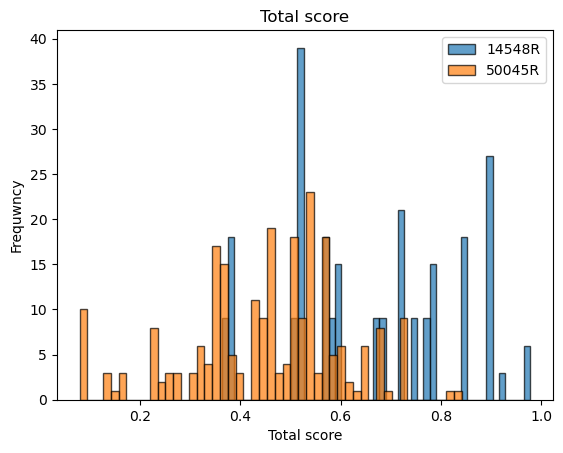

In [154]:
fig, ax = plt.subplots()

subs = df_score['sub'].unique()
for sub in subs:
    sub_df = df_score[df_score['sub'] == sub]

    ax.hist(sub_df['total'], bins=round(len(df_score)/10), edgecolor='black', alpha=0.7, label=sub)

    ax.set_title("Total score")
    ax.set_xlabel('Total score')
    ax.set_ylabel('Frequwncy')
    ax.legend()

In [155]:
# score summary

score_cols = list(chosen_metrics.keys())
df_score[score_cols + ['total']].describe().T

,count,mean,std,min,25%,50%,75%,max
cart_inner_min_angle_worst,486.0,0.664882,0.179606,1.751156e-01,0.503953,0.680640,0.789626,1.000000
cart_inner_scaled_jacobian_worst,486.0,0.282592,0.225016,2.552329e-02,0.063319,0.223552,0.523096,0.848444
cart_inner_aspect_ratio_worst,486.0,0.268079,0.309068,1.524086e-06,0.002581,0.147724,0.513823,1.000000
cart_inner_radius_ratio_worst,486.0,0.495275,0.390036,7.484535e-07,0.063749,0.536217,0.882739,1.000000
tets_vol,486.0,0.728089,0.355269,8.303631e-04,0.665012,0.867201,1.000000,1.000000
total,486.0,0.556442,0.191523,7.955111e-02,0.430990,0.538192,0.685381,0.978349


In [156]:
# Best runs

df_score = df_score.sort_values('total', ascending=False)
top_runs = df_score.head(30)

df_score_param = df_score.merge(
    df_param,
    on=['sub', 'bone', 'run_id'],
    how='left'
)
df_score_param.head(30)

,sub,bone,run_id,cart_inner_min_angle_worst,cart_inner_scaled_jacobian_worst,cart_inner_aspect_ratio_worst,cart_inner_radius_ratio_worst,tets_vol,total,rank_within_case,cgal_params.sizing_field.d0,cgal_params.lloyd.convergence,cgal_params.lloyd.freeze_bound,cgal_params.perturb.sliver_bound,cgal_params.exude.sliver_bound
0,14548R,tpm,24-0b,1.000000,0.848444,1.000000,1.0,1.0,0.978349,2.0,4,0.0100,0.0025,20,0
1,14548R,tpm,51-0b,1.000000,0.848444,1.000000,1.0,1.0,0.978349,2.0,4,0.0050,0.0025,20,0
2,14548R,tpm,78-0b,1.000000,0.848444,1.000000,1.0,1.0,0.978349,2.0,4,0.0025,0.0025,20,0
3,14548R,tpm,26-0b,1.000000,0.825965,1.000000,1.0,1.0,0.975138,5.0,4,0.0100,0.0025,20,20
4,14548R,tpm,80-0b,1.000000,0.825965,1.000000,1.0,1.0,0.975138,5.0,4,0.0025,0.0025,20,20
5,14548R,tpm,53-0b,1.000000,0.825965,1.000000,1.0,1.0,0.975138,5.0,4,0.0050,0.0025,20,20
6,14548R,tpm,25-0b,1.000000,0.626433,0.862375,1.0,1.0,0.926972,8.0,4,0.0100,0.0025,20,10
7,14548R,tpm,79-0b,1.000000,0.626433,0.862375,1.0,1.0,0.926972,8.0,4,0.0025,0.0025,20,10
8,14548R,tpm,52-0b,1.000000,0.626433,0.862375,1.0,1.0,0.926972,8.0,4,0.0050,0.0025,20,10
9,14548R,tpm,63-0b,0.993130,0.603130,0.651719,1.0,1.0,0.892568,18.5,4,0.0025,0.0050,0,0


In [ ]:
# Best accross all subjects

df_grouped_rank = (
    df_score_param
    .groupby(df_param.columns[3:].to_list(), dropna=False)
    .agg(
        mean_rank=('rank_within_case', 'mean'),
        median_rank=('rank_within_case', 'median'),
        best_rank=('rank_within_case', 'min'),
        n_runs=('rank_within_case', 'size')
    )
    .reset_index()
    .sort_values('mean_rank')
)
df_grouped_rank

,cgal_params.sizing_field.d0,cgal_params.lloyd.convergence,cgal_params.lloyd.freeze_bound,cgal_params.perturb.sliver_bound,cgal_params.exude.sliver_bound,mean_rank,median_rank,best_rank,n_runs
27,2,0.0050,0.0025,0,0,17.00,17.00,2.0,2
141,4,0.0100,0.0025,20,0,17.75,17.75,2.0,2
114,4,0.0050,0.0025,20,0,17.75,17.75,2.0,2
0,2,0.0025,0.0025,0,0,18.75,18.75,5.5,2
30,2,0.0050,0.0025,10,0,18.75,18.75,5.5,2
...,...,...,...,...,...,...,...,...,...
202,8,0.0050,0.0050,10,10,234.00,234.00,230.0,2
229,8,0.0100,0.0050,10,10,234.50,234.50,230.0,2
238,8,0.0100,0.0100,10,10,239.50,239.50,239.0,2
184,8,0.0025,0.0100,10,10,240.00,240.00,239.0,2


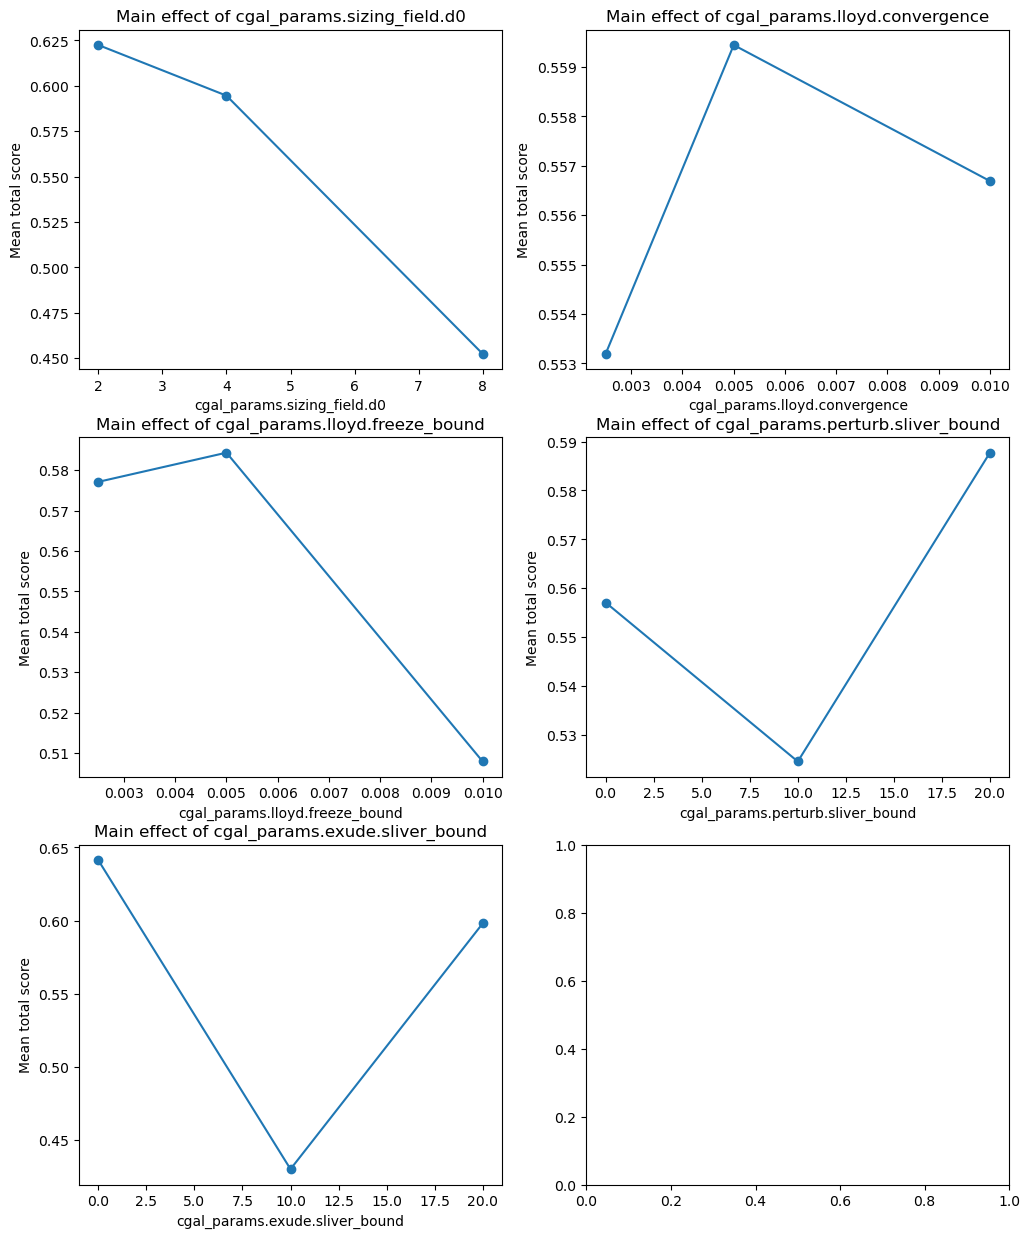

In [159]:
fig, ax = plt.subplots(3, 2, figsize=(12, 15))
ax = ax.flatten()

for i, p in enumerate(df_param.columns[3:]):
    eff = (
        df_score_param
        .groupby(p)['total']
        .mean()
        .reset_index()
        .sort_values(p)
    )

    ax[i].plot(eff[p], eff['total'], marker='o')
    ax[i].set_title(f'Main effect of {p}')
    ax[i].set_xlabel(p)
    ax[i].set_ylabel('Mean total score')
